In [1]:
%load_ext autoreload
%autoreload 2

In [11]:
from pathlib import Path
from utils.run_estimation import run_state_estimation
from utils.ekf_utils import load_custom_dataset
from utils.plot_data import *

In [3]:
sim_num = 3
dataset_num = 3
data = load_custom_dataset(dataset_path=Path.cwd().parent / f"custom_datasets/quad_dataset_run{dataset_num}.npz", sim_num=sim_num)

Data loaded from /home/jad/Uni/semester-2/RL-IP/mpx/custom_datasets/quad_dataset_run3.npz.


In [12]:
start = 0
end = len(data["dt"])

result, kf = run_state_estimation(dt=data["dt"][0],
                                  init_pos=data["base_pos"][0],
                                  base_orient=data["base_orient"],
                                  base_ang_vel=data["base_ang_vel"],
                                  joint_pos=data["joint_pos"],
                                  joint_vel=data["joint_vel"],
                                  joint_acc=data["joint_acc"],
                                  contact_states=data["contact_states"],
                                  contact_forces=data["contact_forces"],
                                  contact_pos=data["contact_pos"],
                                  Q=0.002,
                                  R=0.01)

Estimating base_acc.


Estimating state: 100%|██████████| 5000/5000 [00:07<00:00, 632.85it/s] 


0 0


- rodrigues doesnt return valid rot matrix: R @ R.T != I
-> maybe rodrigues is not correct?

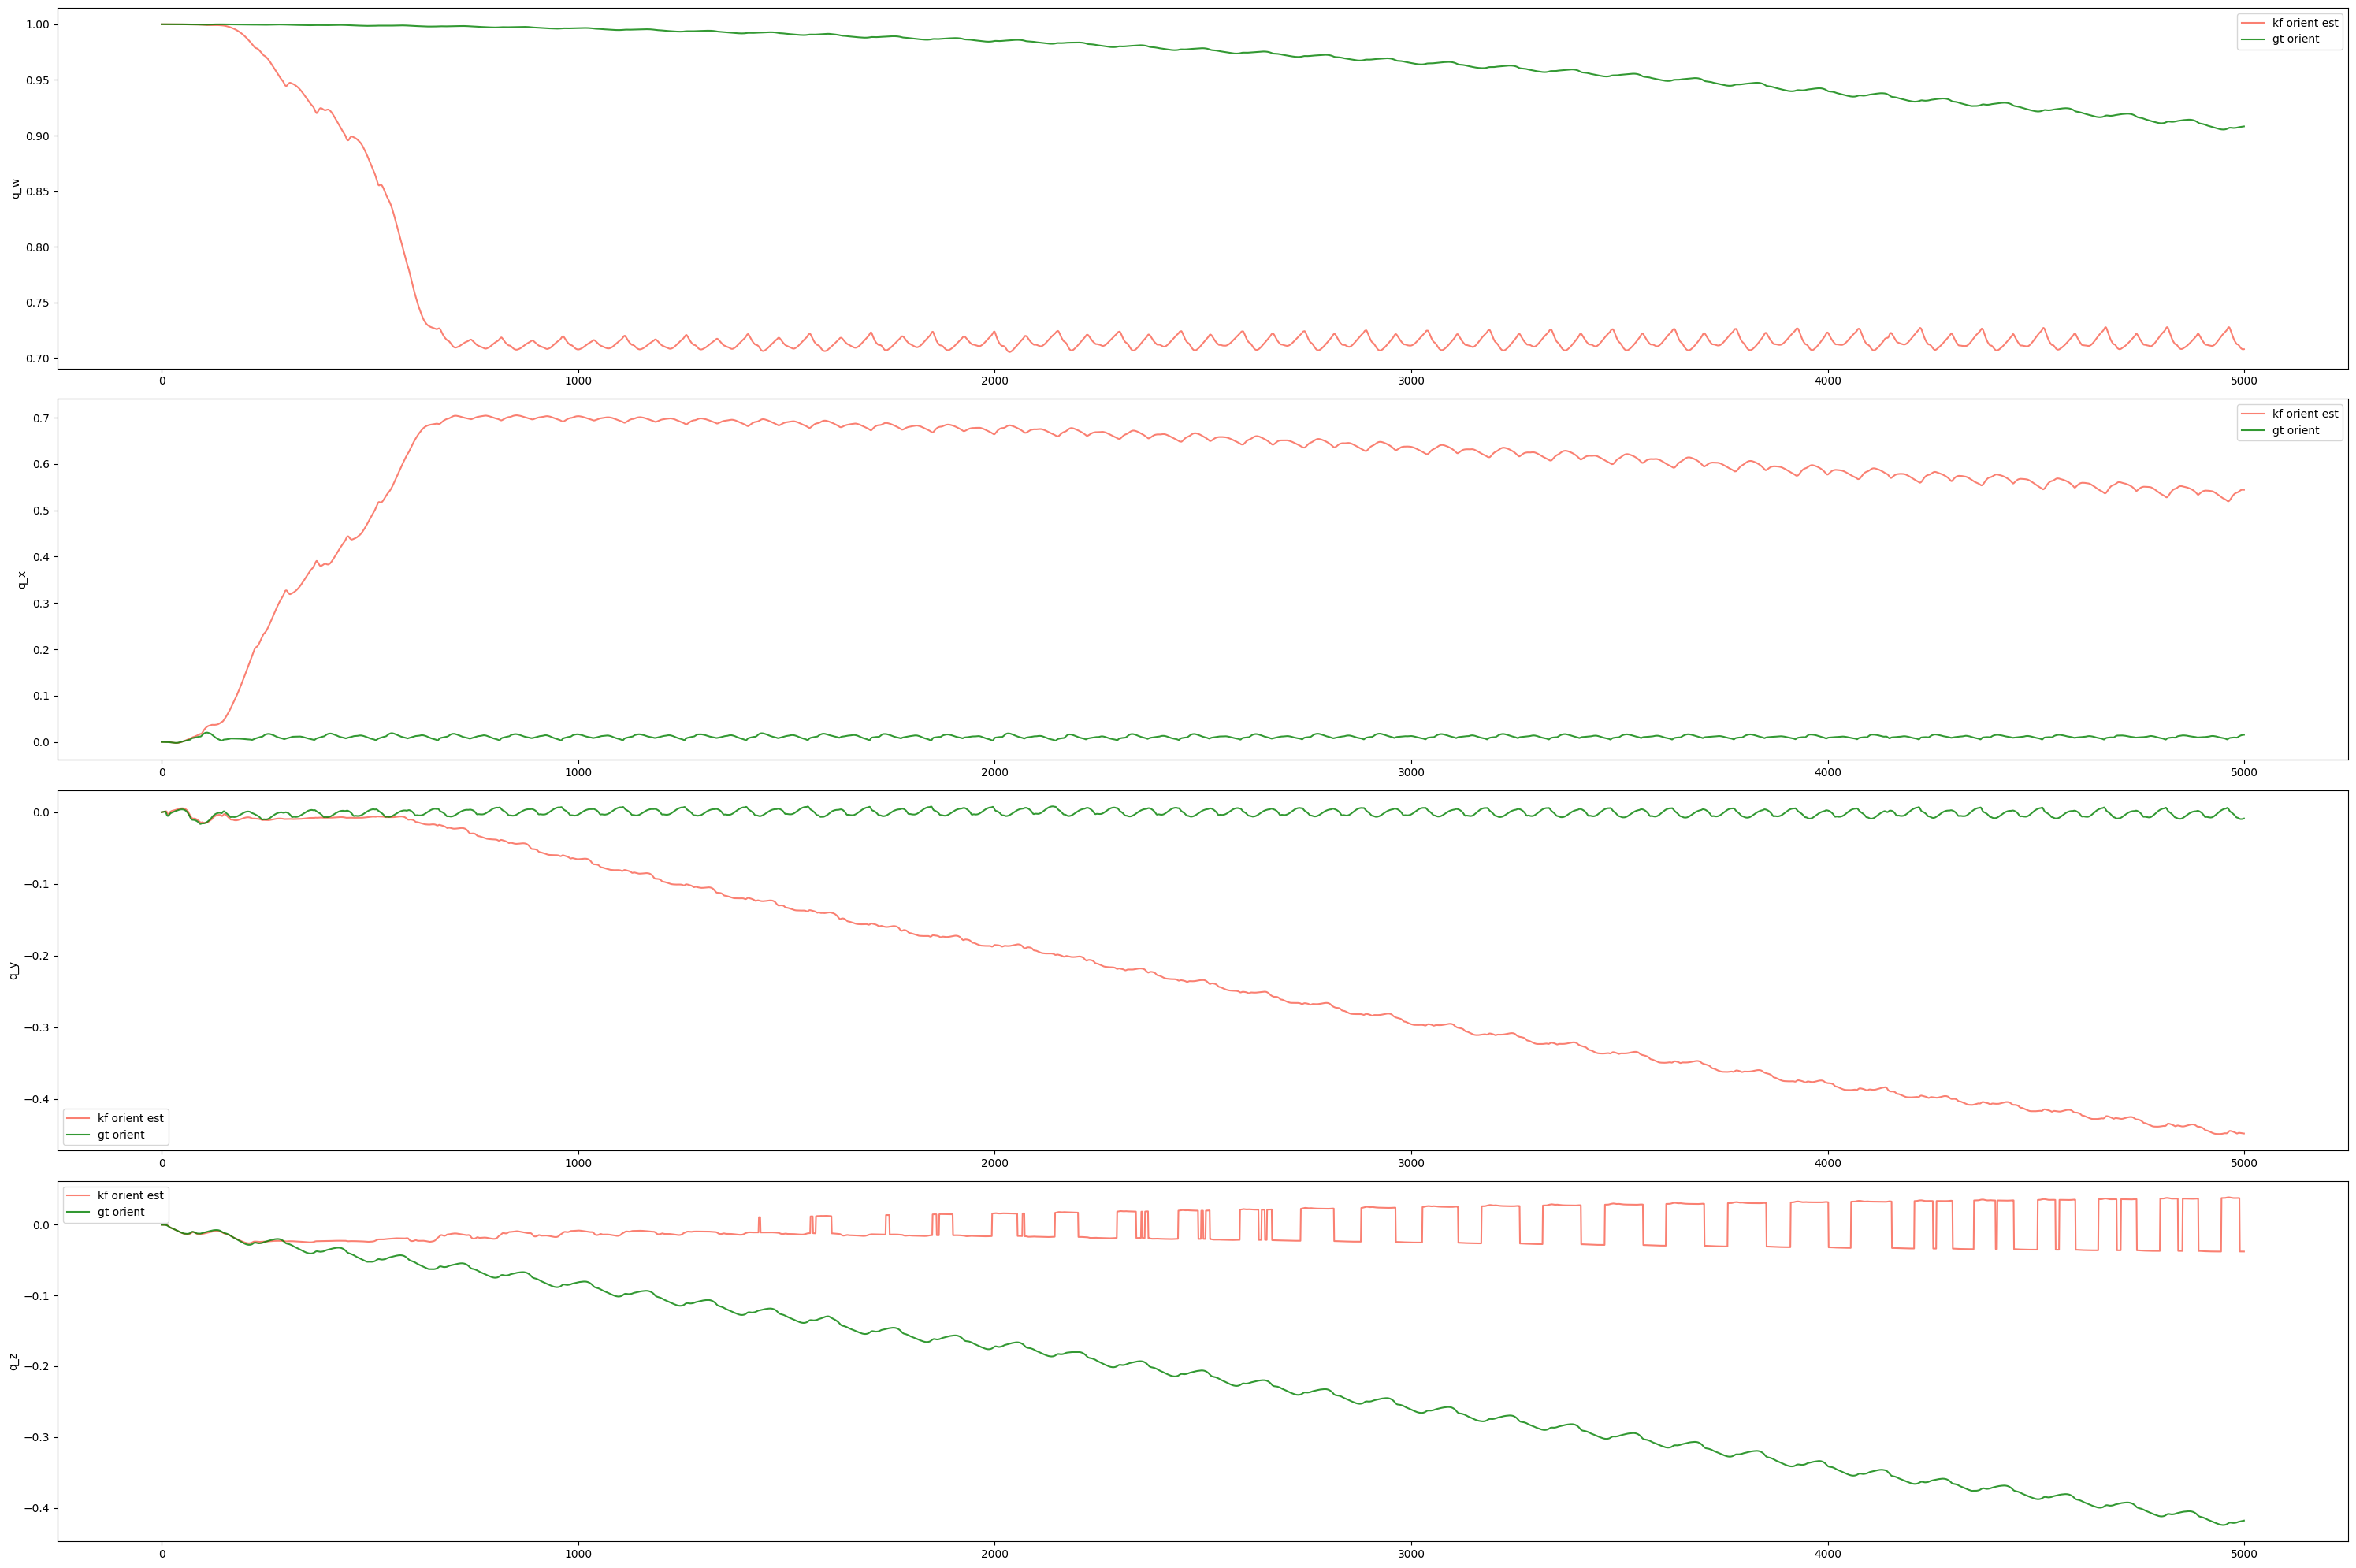

In [21]:
from utils.ekf_utils import rot_to_quat

fig, axes = plt.subplots(4, 1, figsize=(30,20))

gt_orient = data["base_orient"]
orient_est = result["orient_update"]
num_point = 5000

orient_est_quat = []
for orient in orient_est:
    quat = rot_to_quat(orient)
    orient_est_quat.append(quat)
orient_est_quat = np.array(orient_est_quat)

labels = ['w', 'x', 'y', 'z']
for i in range(4):
    axes[i].plot(np.arange(num_point), orient_est_quat[:num_point, i], label="kf orient est", color="salmon")
    axes[i].plot(np.arange(num_point), gt_orient[:num_point, i], label="gt orient", alpha=0.8, color="green")
    axes[i].set_ylabel(f'q_{labels[i]}')
    axes[i].legend()

plt.tight_layout()
plt.show()

In [63]:
from utils.ekf_utils import rodrigues

orient = np.array([[1,2,3],[4,5,6],[7,8,9]])
alpha = np.array([[0.2,0.5,0.3], [0.1, 0.05, 0.85], [0,1,0]])
res = alpha@orient
print(alpha)
print(orient)
print(res)
print(res.flatten())
print()

orient_flat = orient.flatten()
big_alpha = np.block([[a * np.eye(3) for a in row] for row in alpha])
print(big_alpha @ orient_flat)

A = np.eye(18)
A[3:12, 3:12] = zeros

[[0.2  0.5  0.3 ]
 [0.1  0.05 0.85]
 [0.   1.   0.  ]]
[[1 2 3]
 [4 5 6]
 [7 8 9]]
[[4.3  5.3  6.3 ]
 [6.25 7.25 8.25]
 [4.   5.   6.  ]]
[4.3  5.3  6.3  6.25 7.25 8.25 4.   5.   6.  ]

[4.3  5.3  6.3  6.25 7.25 8.25 4.   5.   6.  ]


Problem here is there is no measurement for angular velocity. Leg odometry only provides one for linear velocity since usually angular velocity comes from IMU. This can be used for leg kilo data, but how about simulated data?

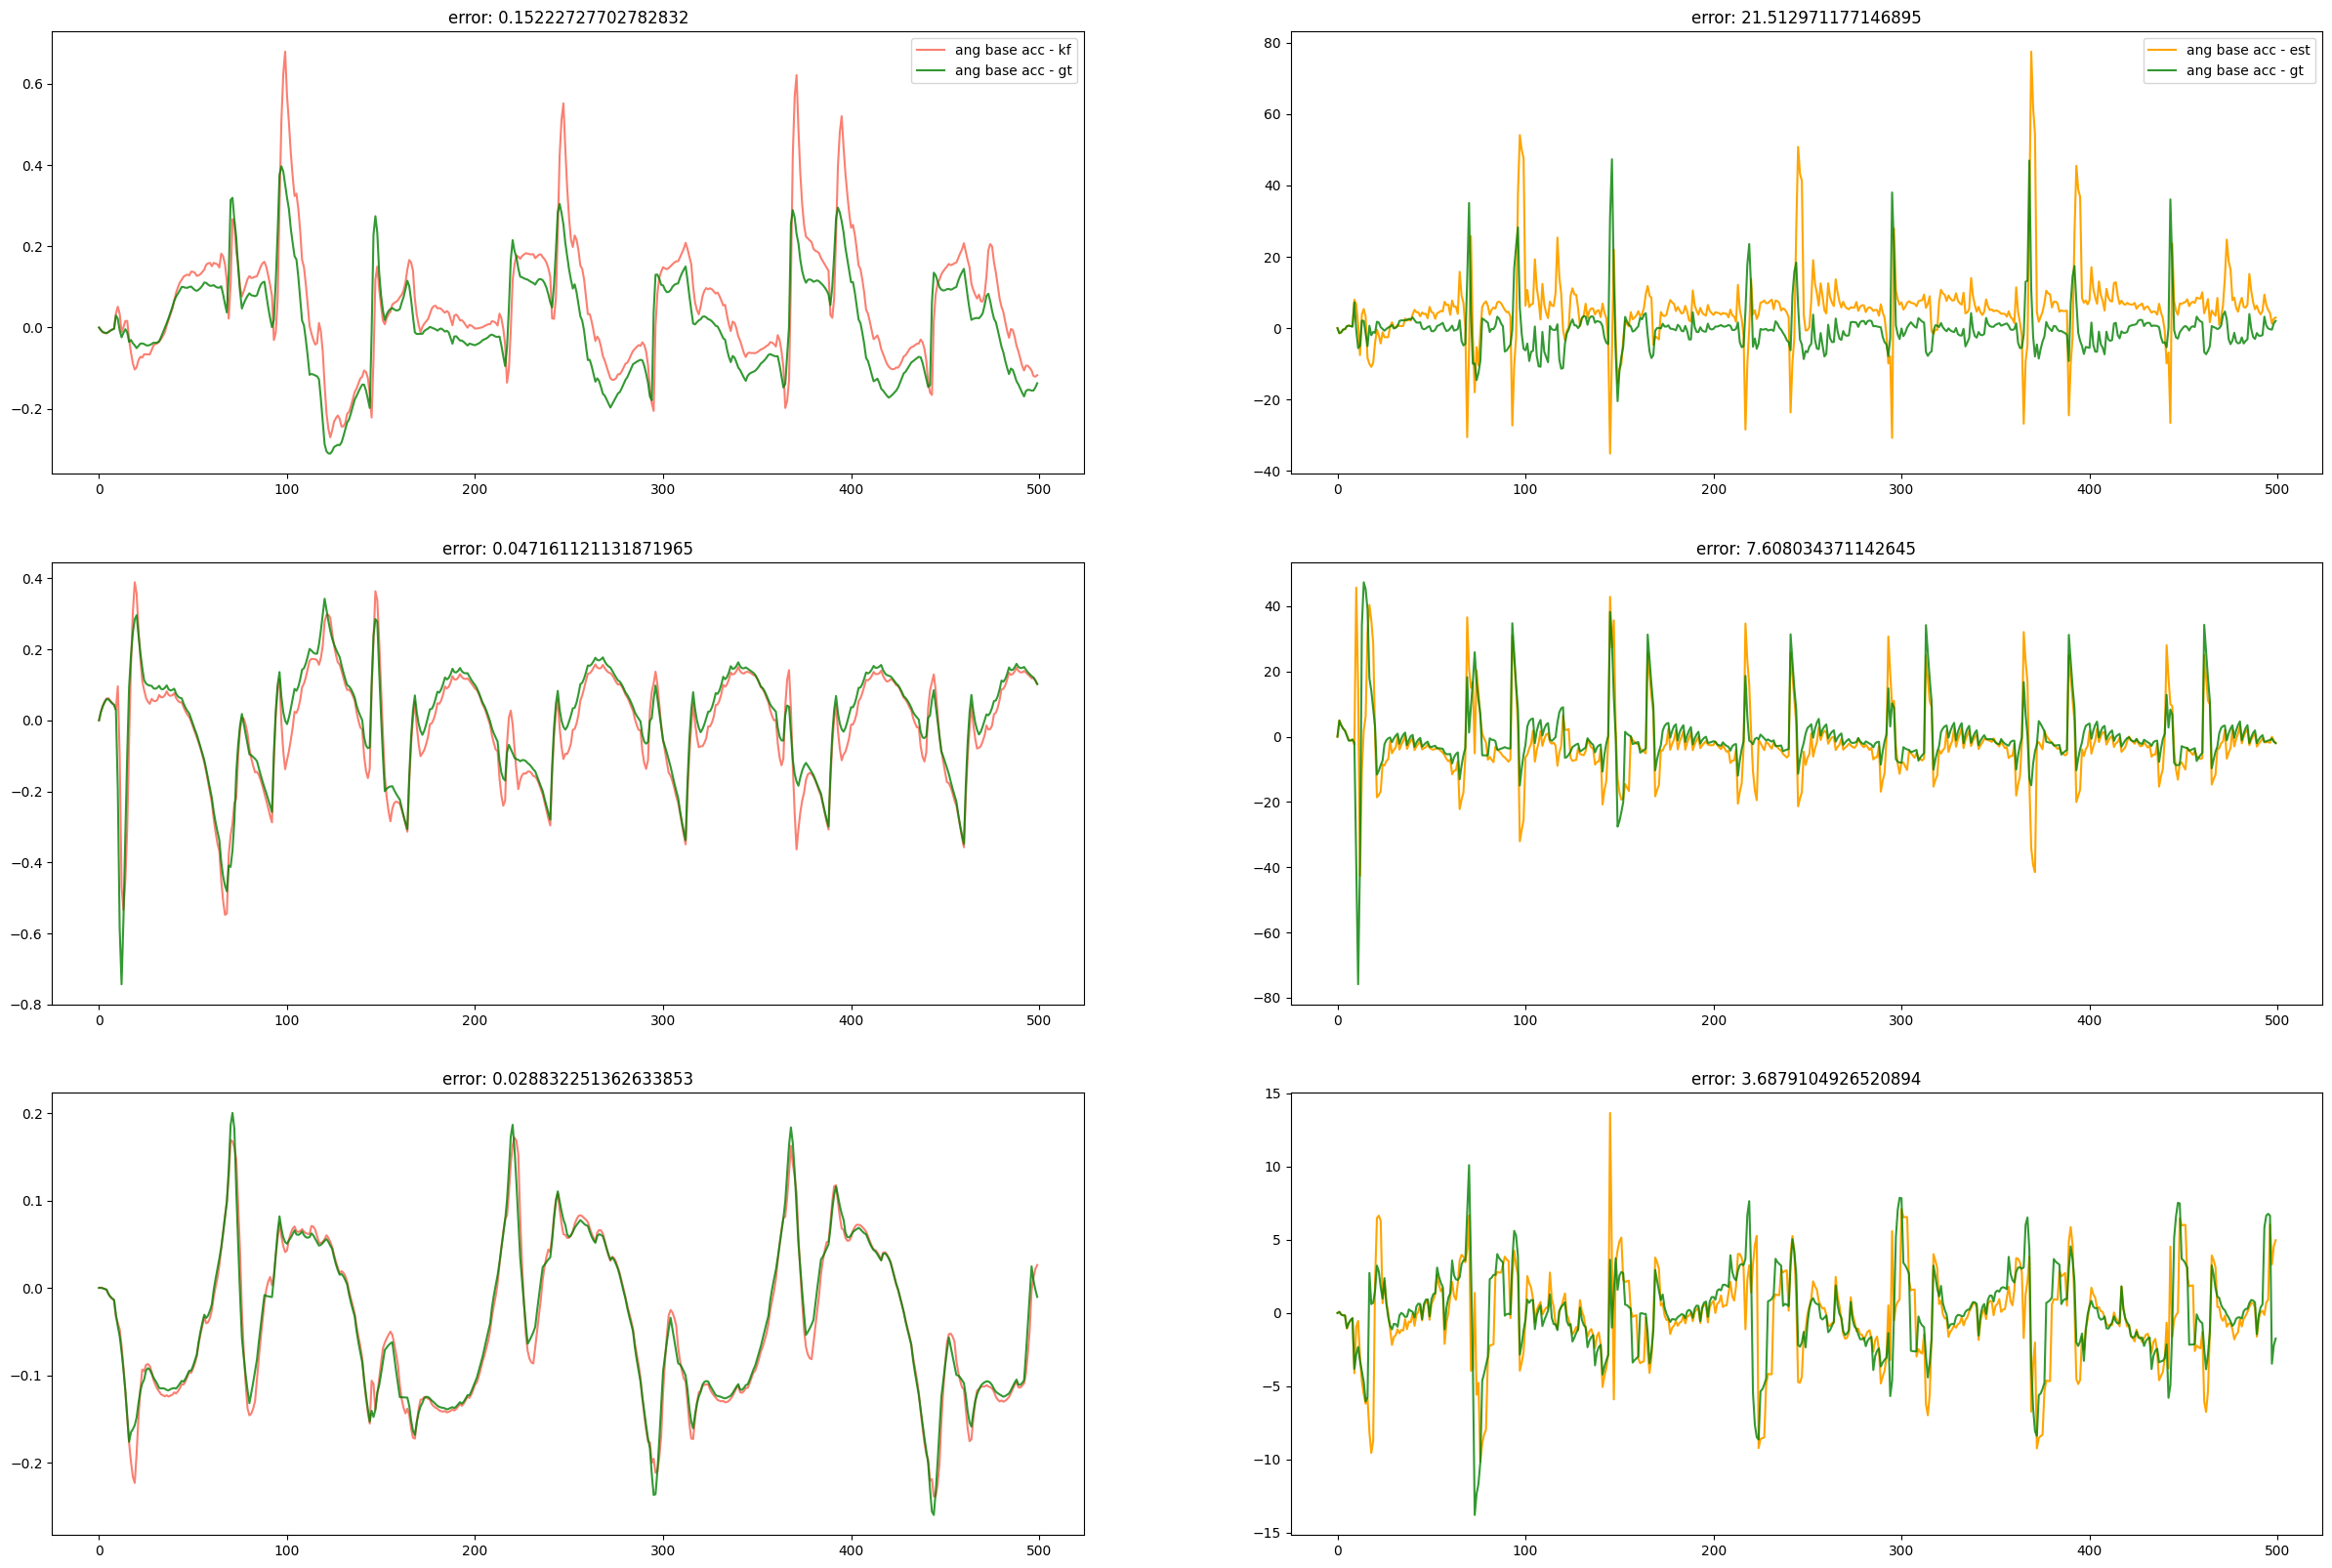

In [79]:
fig, axes = plt.subplots(3, 2, figsize=(30,20))

est = result["base_acc3_est"]
gt_acc = data["base_acc"]
gt_vel = data["base_ang_vel"]
kf_est = result["ang_vel_update_sim"]
num_point = 500

for i in range(3):
    # plot lin acc
    axes[i][0].plot(np.arange(num_point), kf_est[:num_point, i], label="ang base acc - kf", color="salmon")
    axes[i][0].plot(np.arange(num_point), gt_vel[:num_point, i], label="ang base acc - gt", alpha=0.8, color="green")

    # plot ang acc
    axes[i][1].plot(np.arange(num_point), est[:num_point, i+3], label="ang base acc - est", color="orange")
    axes[i][1].plot(np.arange(num_point), gt_acc[:num_point, i+3], label="ang base acc - gt", alpha=0.8, color="green")

    error_1 = np.sqrt(np.mean((gt_vel[:,i] - kf_est[:, i])**2, axis=0))
    error_2 = np.sqrt(np.mean((gt_acc[:,i+3] - est[:, i+3])**2, axis=0))

    axes[i][0].set_title(f"error: {error_1}")
    axes[i][1].set_title(f"error: {error_2}")

for col in range(2):
    handles, labels = axes[0, col].get_legend_handles_labels()
    axes[0, col].legend(handles, labels, loc="upper right")

plt.show()

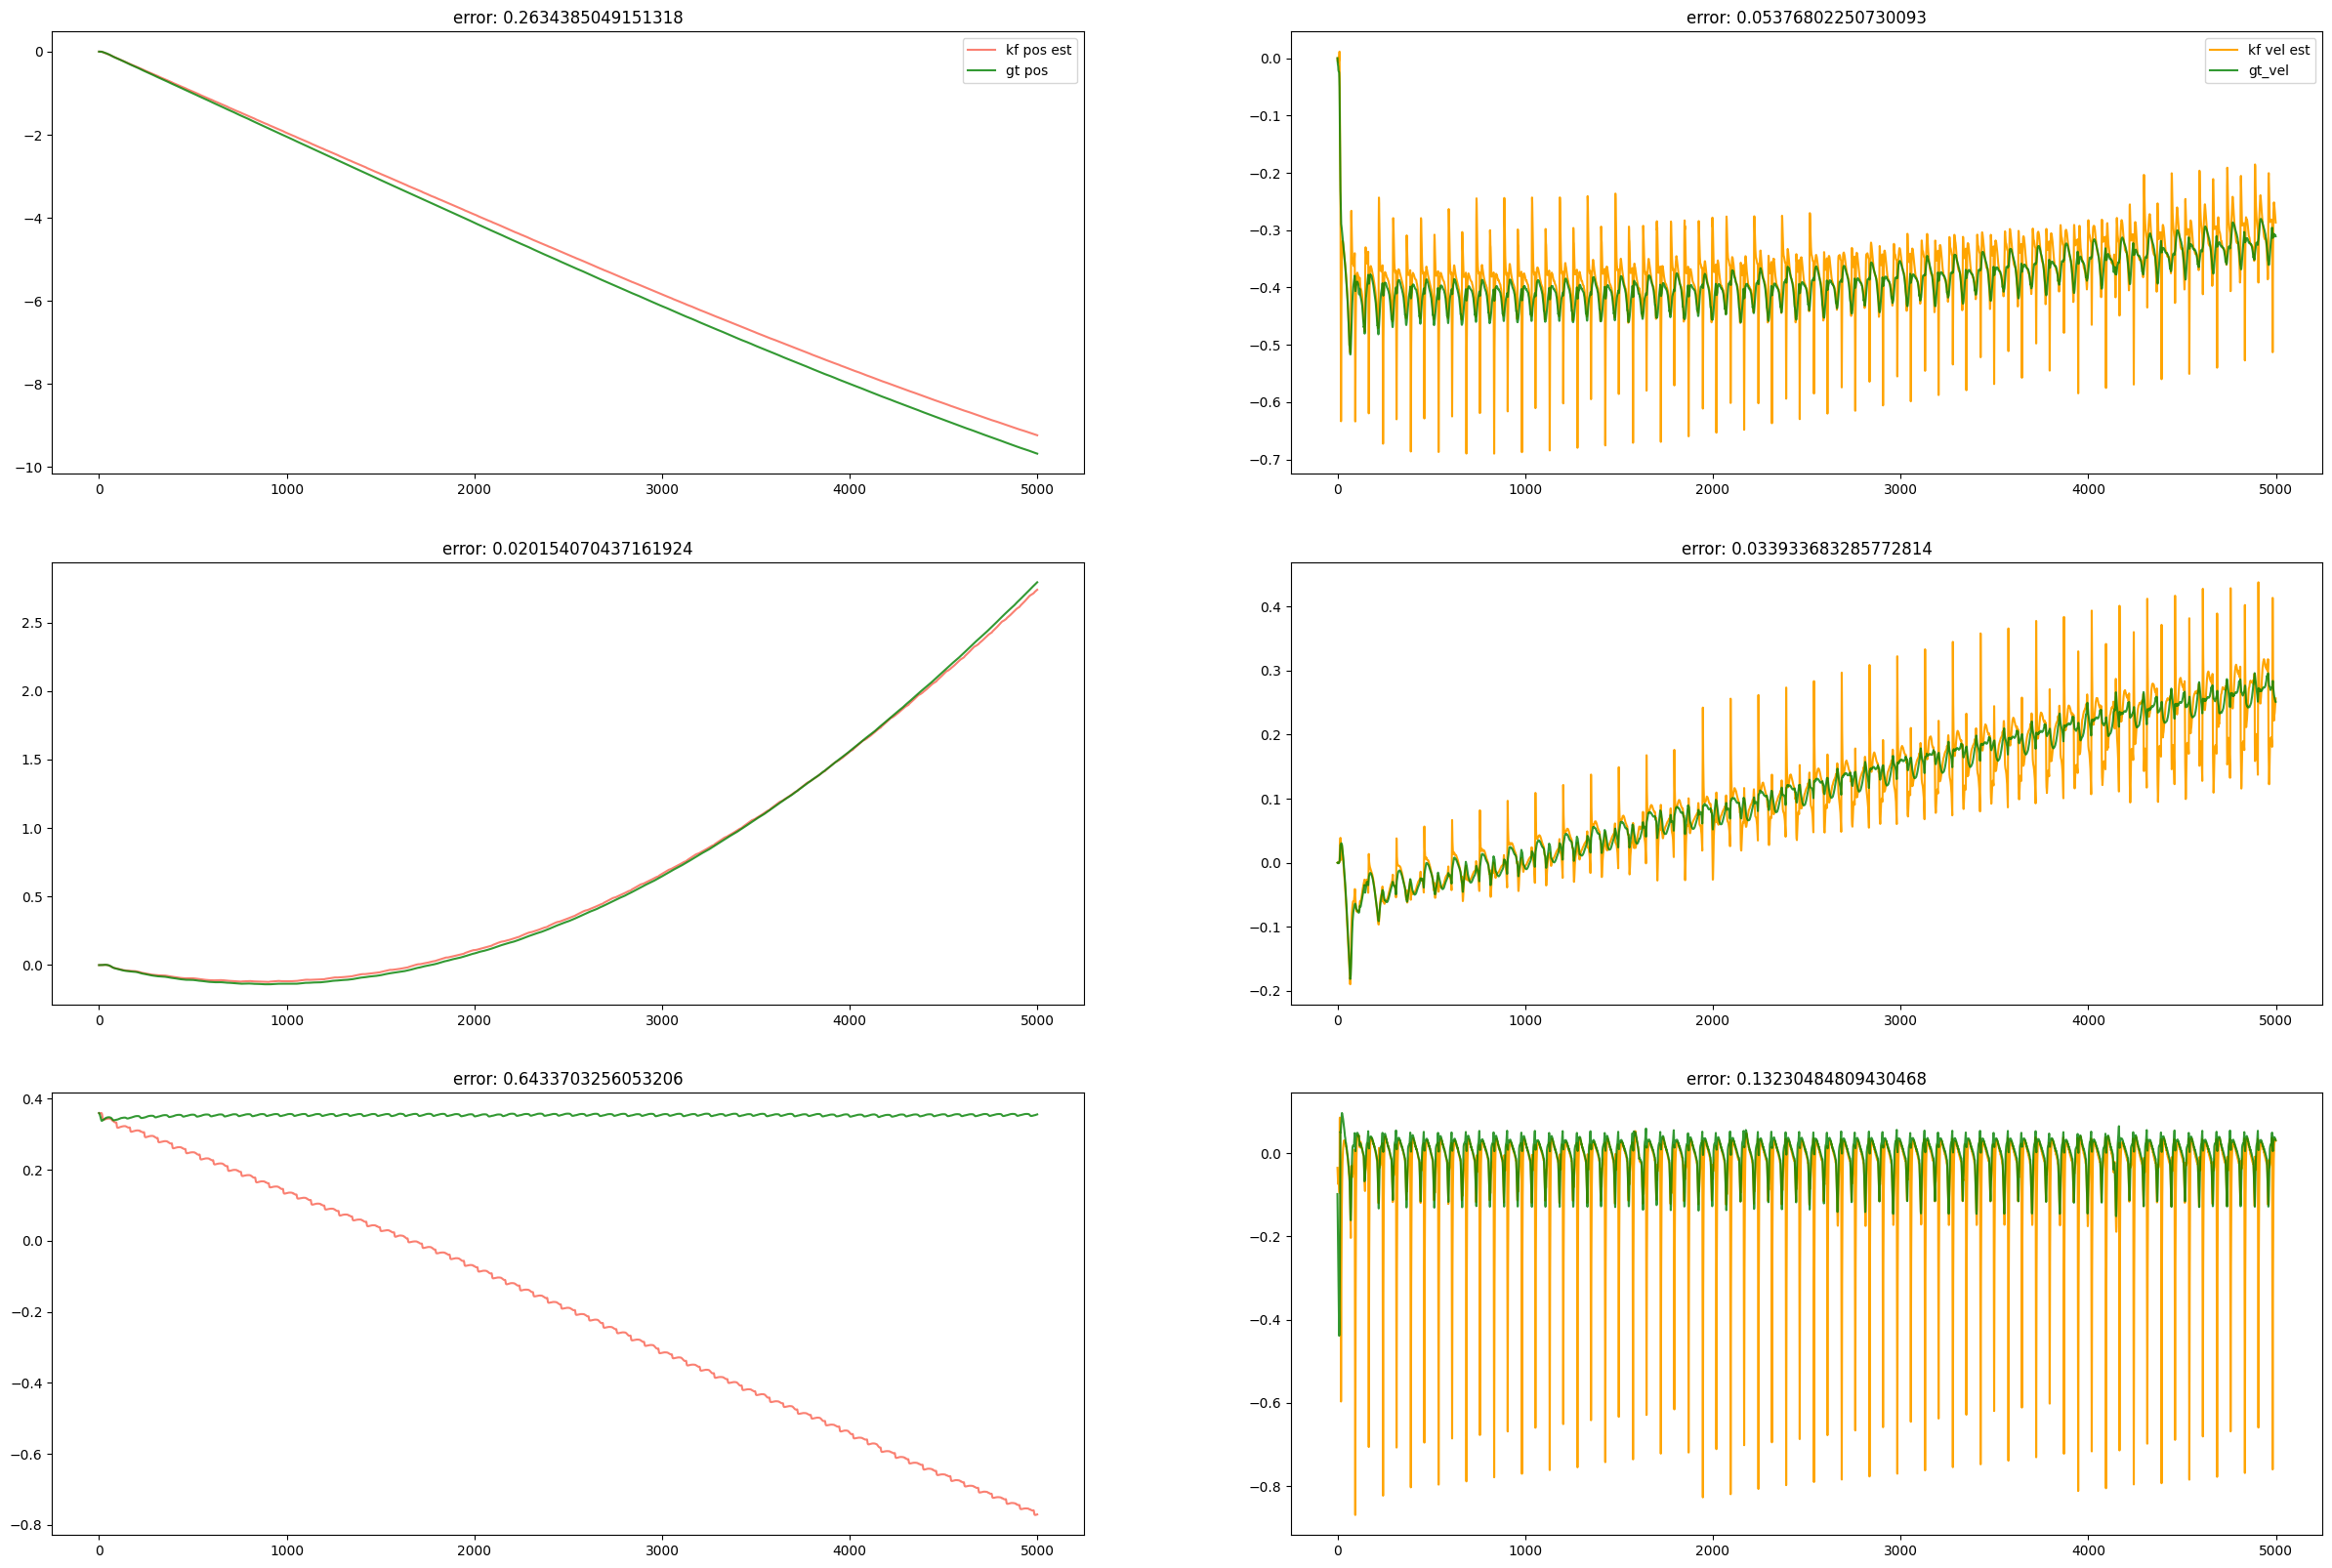

In [23]:
fig, axes = plt.subplots(3, 2, figsize=(30,20))

gt_pos = data["base_pos"]
pos_est = result["pos_update"]
gt_vel = data["base_vel"]
vel_est = result["vel_update"]
num_point = 5000

for i in range(3):
    # plot lin acc
    axes[i][0].plot(np.arange(num_point), pos_est[:num_point, i], label="kf pos est", color="salmon")
    axes[i][0].plot(np.arange(num_point), gt_pos[:num_point, i], label="gt pos", alpha=0.8, color="green")

    # plot ang acc
    axes[i][1].plot(np.arange(num_point), vel_est[:num_point, i], label="kf vel est", color="orange")
    axes[i][1].plot(np.arange(num_point), gt_vel[:num_point, i], label="gt_vel", alpha=0.8, color="green")

    error_1 = np.sqrt(np.mean((gt_pos[:,i] - pos_est[:, i])**2, axis=0))
    error_2 = np.sqrt(np.mean((gt_vel[:,i] - vel_est[:, i])**2, axis=0))

    axes[i][0].set_title(f"error: {error_1}")
    axes[i][1].set_title(f"error: {error_2}")

for col in range(2):
    handles, labels = axes[0, col].get_legend_handles_labels()
    axes[0, col].legend(handles, labels, loc="upper right")

plt.show()

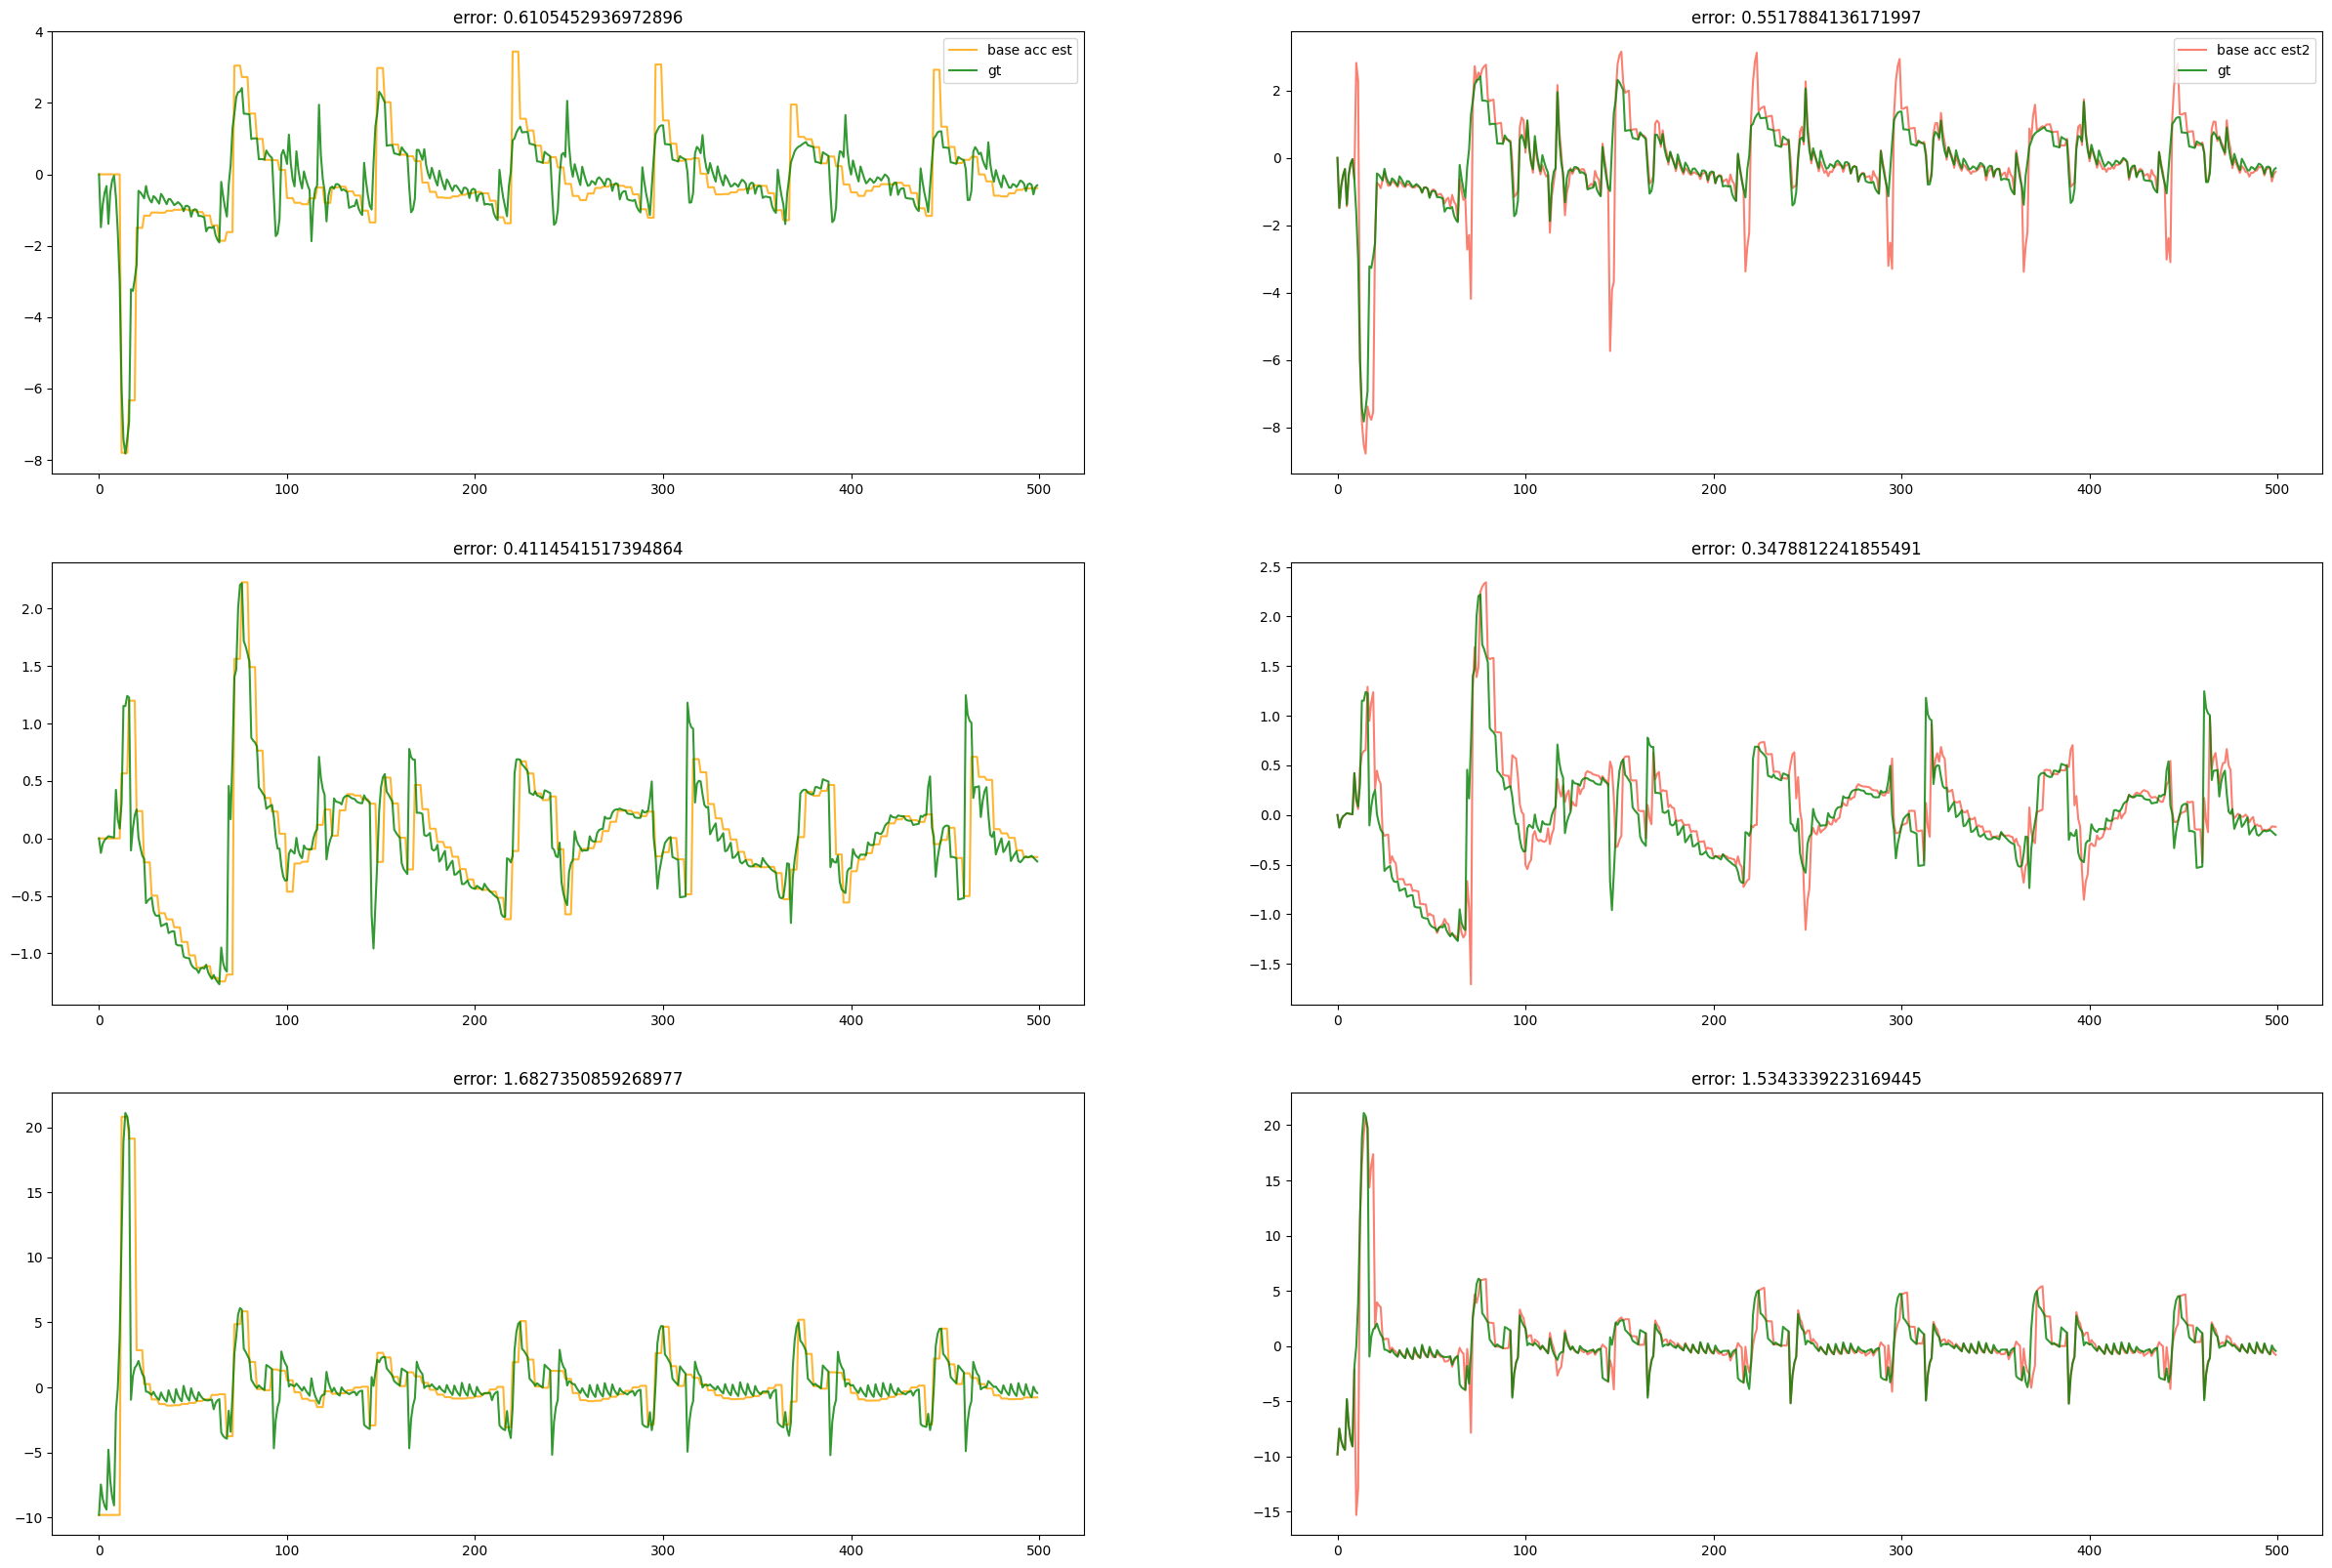

In [30]:
fig, axes = plt.subplots(3, 2, figsize=(30,20))

est_1 = result["base_acc_est"]
est_2 = result["base_acc2_est"]
gt = data["base_acc"]
num_point = 500

for i in range(3):
    axes[i][0].plot(np.arange(num_point), est_1[:num_point, i], label="base acc est", alpha=0.8, color="orange")
    axes[i][1].plot(np.arange(num_point), est_2[:num_point, i], label="base acc est2", color="salmon")

    axes[i][0].plot(np.arange(num_point), gt[:num_point, i], label="gt", alpha=0.8, color="green")
    axes[i][1].plot(np.arange(num_point), gt[:num_point, i], label="gt", alpha=0.8, color="green")

    error_1 = np.sqrt(np.mean((gt[:,i] - est_1[:, i])**2, axis=0))
    error_2 = np.sqrt(np.mean((gt[:,i] - est_2[:, i])**2, axis=0))

    axes[i][0].set_title(f"error: {error_1}")
    axes[i][1].set_title(f"error: {error_2}")

for col in range(2):
    handles, labels = axes[0, col].get_legend_handles_labels()
    axes[0, col].legend(handles, labels, loc="upper right")

plt.show()

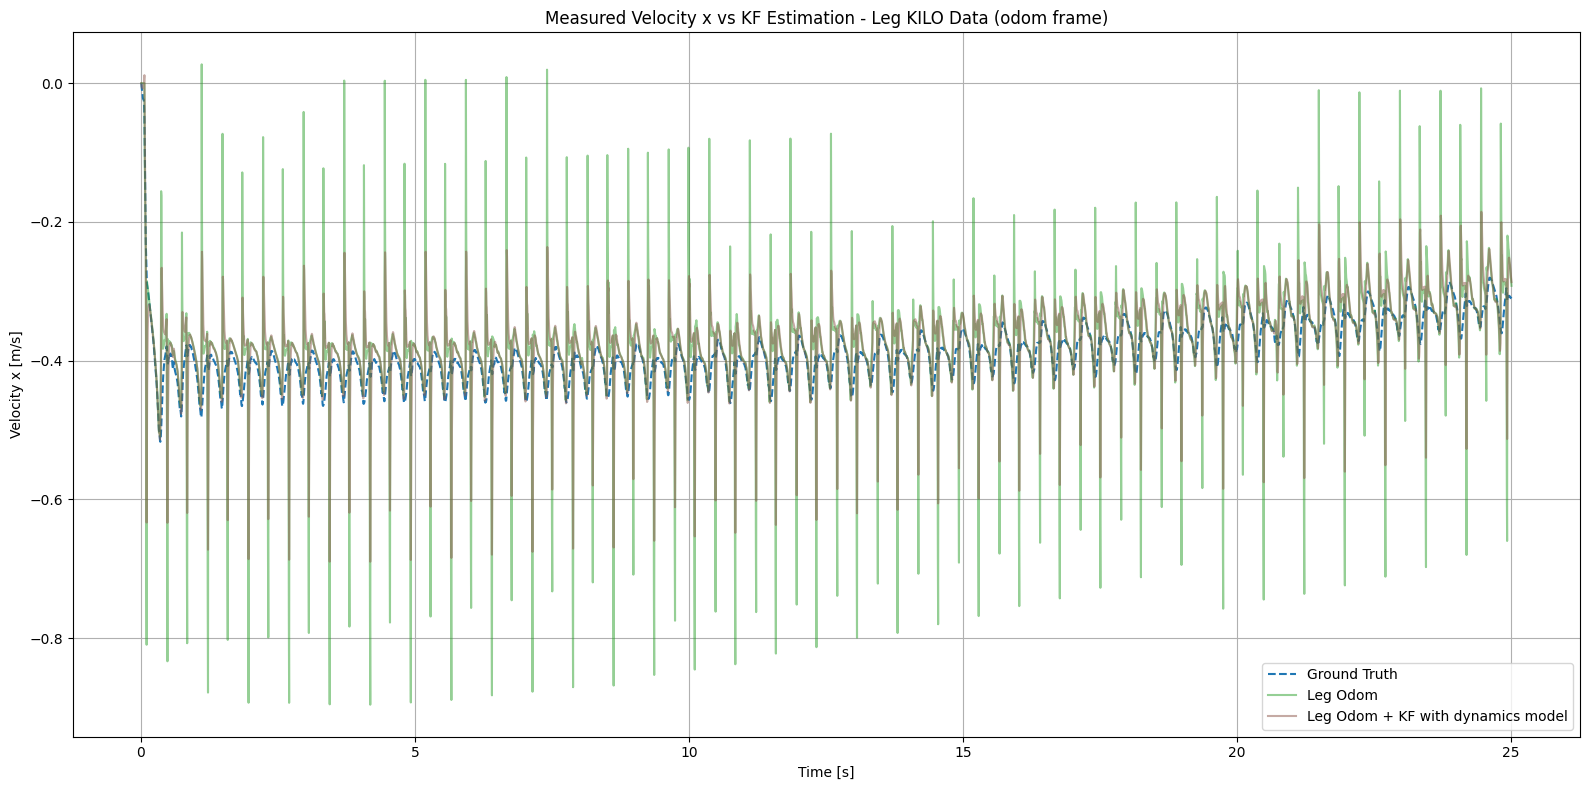

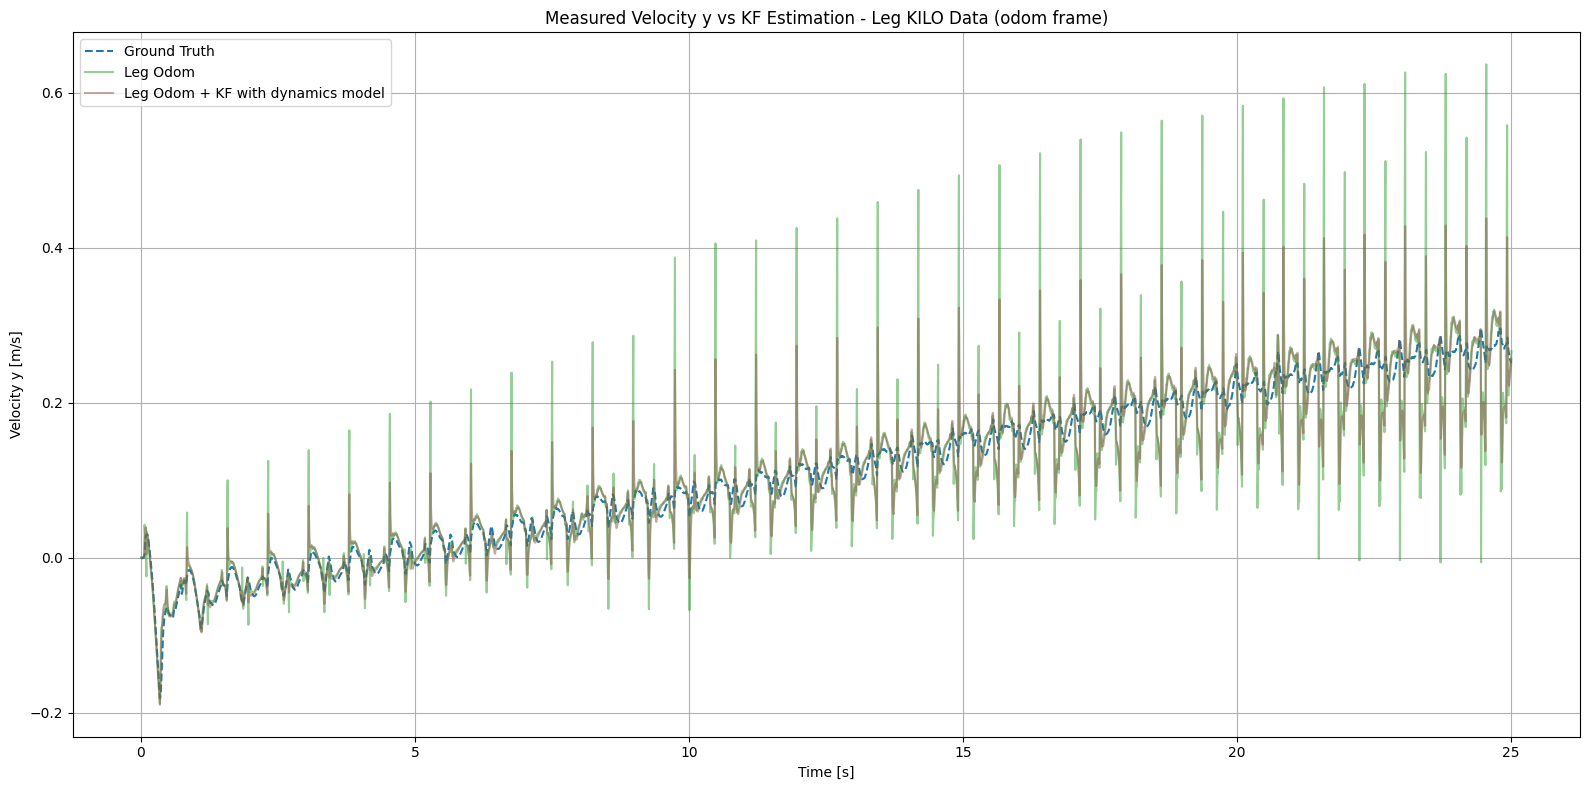

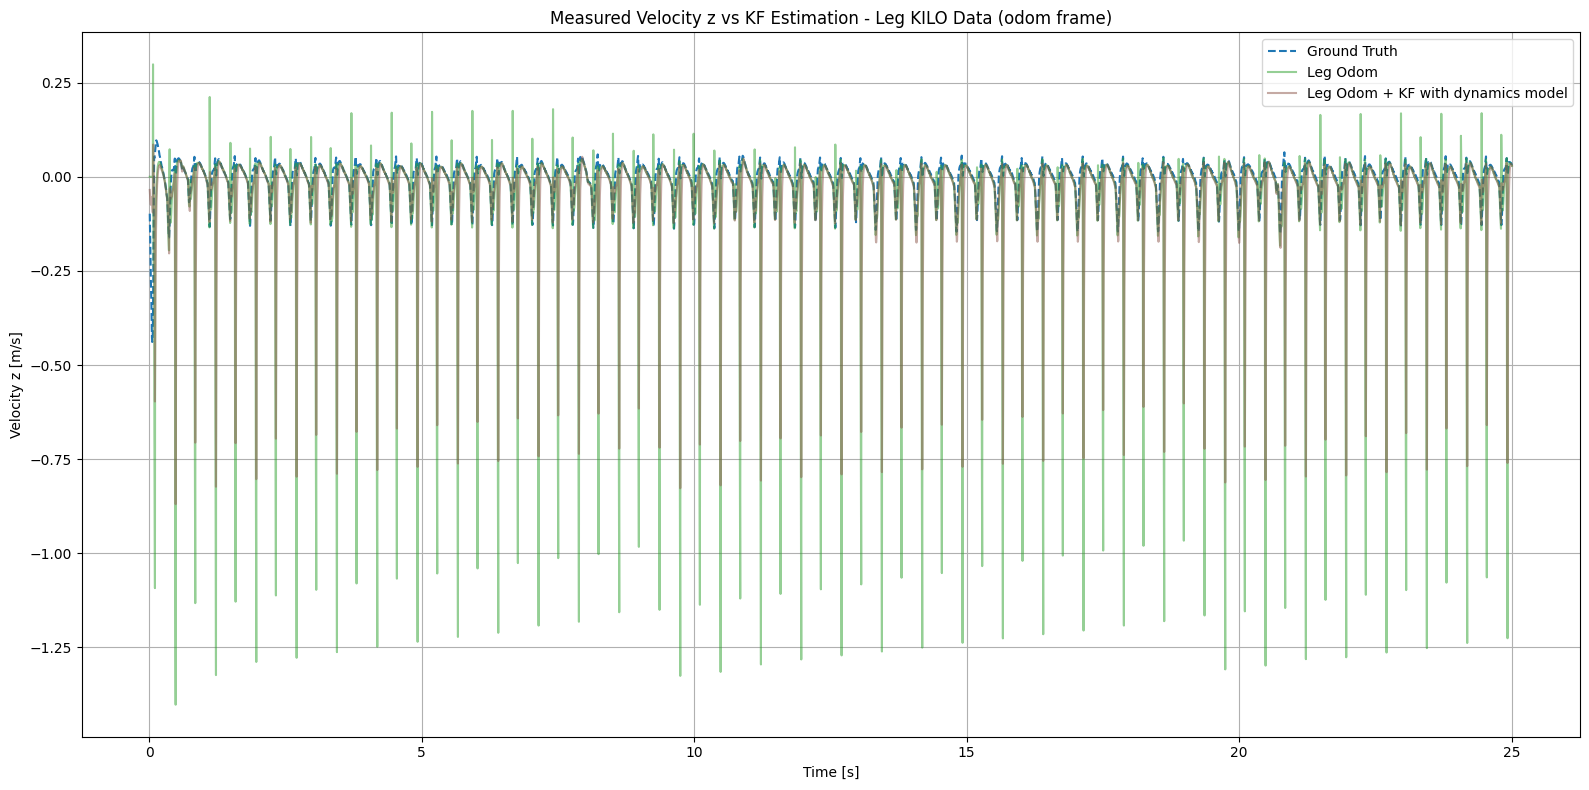

In [33]:
# Odom frame

colors = ['#1f77b4', # gt
        '#2ca02c', # leg odom
        '#8c564b'  # leg odom + kf, dynamics with est cf
        ]

dim = ["x", "y", "z"]
num_data_points = len(data["dt"])

for i in range(len(dim)):
    gt_values = data["base_vel"][:num_data_points, i:i+1]

    pred_values = [result["leg_odom"][:num_data_points, i:i+1],
                   result["vel_update"][:num_data_points, i:i+1]]

    pred_labels = ["Leg Odom", "Leg Odom + KF with dynamics model"]

    compare_estimation_plot(time=data["time"][:num_data_points],
                            gt_values=gt_values,
                            gt_label=["Ground Truth"],
                            pred_values=pred_values,
                            pred_labels=pred_labels,
                            ylabel=f"Velocity {dim[i]} [m/s]",
                            title=f"Measured Velocity {dim[i]} vs KF Estimation - Leg KILO Data (odom frame)",
                            colors=colors
                            )